In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PowerTransformer

import catboost

In [64]:
seed = 42

# Data

In [65]:
pt = PowerTransformer(method="yeo-johnson", standardize=True)

def extract_engine_size(engine: pd.Series) -> pd.Series:
    """Extract numeric displacement in litres; fallback to median if missing."""
    nums = engine.str.extract(r'(\d+\.?\d*)L')[0].astype(float)
    return nums.fillna(nums.median())

def add_domain_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add hard-coded engineered features."""
    out = df.copy()
    
    out['age'] = 2025 - out['year'].astype(np.int64)
    out['is_luxury'] = out['make'].str.lower().isin(
        {'bmw', 'mercedes-benz', 'audi', 'lexus', 'porsche', 'jaguar', 'land rover'})
    
    out['is_electric'] = out['fuel'].str.lower().eq('electric')
    out['is_deisel'] = out['fuel'].str.lower().eq('diesel')
    
    out['engine_L'] = extract_engine_size(out['engine'])

    # interaction
    out['age_x_mileage'] = out['age'] * out['mileage']
    
    return out

def make_dummies(df: pd.DataFrame, min_freq=3):
    cat = df.select_dtypes('object')
    df = pd.get_dummies(df, columns=cat.columns, drop_first=True)
    rare = df.columns[df.sum() < min_freq]
    return df.drop(columns=rare)

def clean(df_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_raw.copy()
    df = df.drop(columns=['id'], errors='ignore')
    
    # cylinders
    df['cylinders'] = df['cylinders'].fillna(99).astype(int)

    # impute
    for col in df.columns[df.isna().any()]:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode().iloc[0])
        else:
            df[col] = df[col].fillna(df[col].median())
    
    df['year'] = df['year'].astype(str)
    return df

In [66]:
train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")

train_ids = train["id"]
test_ids  = test["id"]

In [67]:
train.head()

,id,name,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,1,2024 INFINITI QX50 SPORT,INFINITI,QX50,2024,49404.0,ER,4.0,Gasoline,7.0,(CVT) CONT VAR.,SPORT,NaN,4.0,Radiant White,Monaco Red,Front-wheel Drive
1,2,2024 Mazda CX-90 PHEV Base,Mazda,CX-90 PHEV,2024,55399.0,"TIV-G 2.5L I-4 gasoline direct injection, DOHC...",4.0,Gasoline,2.0,8-Speed Automatic,Base,SUV,4.0,Soul Red Crystal Metallic,Griege,All-wheel Drive
2,3,2024 Honda CR-V Hybrid Sport Touring,Honda,CR-V Hybrid,2024,42005.0,16V GDI DOHC Hybrid,4.0,Hybrid,1.0,Automatic CVT,Sport Touring,SUV,4.0,Radiant Red Metallic,Black,All-wheel Drive
3,4,2024 Jeep Grand Cherokee L Limited,Jeep,Grand Cherokee L,2024,52567.0,OHV,6.0,Gasoline,246.0,8-Speed Automatic,Limited,SUV,4.0,Velvet Red Pearlcoat,Global Black,Four-wheel Drive
4,5,2024 Acura MDX Technology,Acura,MDX,2024,56800.0,24V GDI SOHC,6.0,Gasoline,5.0,10-Speed Automatic,Technology,SUV,4.0,Gray,NaN,Front-wheel Drive


In [68]:
full = pd.concat([train, test], axis=0, ignore_index=True)
full = add_domain_features(clean(full))
full = make_dummies(full)

# split back
X_full = full.drop(columns=["price"], errors="ignore")
y_full = full["price"].to_numpy(copy=True).reshape(-1, 1)

# transform target once on the whole vector to avoid leakage
y_full = pt.fit_transform(y_full).ravel()

X = X_full.loc[X_full.index[:len(train)]]
y = y_full[:len(train)]
test  = X_full.loc[X_full.index[len(train):]]

df1 = train.copy()
df1["price"] = df1["price"].fillna(0)

# EDA

In [69]:
train.isna().sum().sort_values(ascending=False)

cylinders         105
interior_color     38
mileage            34
price              23
fuel                7
doors               7
exterior_color      5
body                3
engine              2
transmission        2
trim                1
id                  0
year                0
name                0
make                0
model               0
drivetrain          0
dtype: int64

In [70]:
X.isna().sum().sum() # total number of NaNs in whole df

np.int64(0)

In [71]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802 entries, 0 to 801
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              802 non-null    int64  
 1   name            802 non-null    object 
 2   make            802 non-null    object 
 3   model           802 non-null    object 
 4   year            802 non-null    int64  
 5   price           779 non-null    float64
 6   engine          800 non-null    object 
 7   cylinders       697 non-null    float64
 8   fuel            795 non-null    object 
 9   mileage         768 non-null    float64
 10  transmission    800 non-null    object 
 11  trim            801 non-null    object 
 12  body            799 non-null    object 
 13  doors           795 non-null    float64
 14  exterior_color  797 non-null    object 
 15  interior_color  764 non-null    object 
 16  drivetrain      802 non-null    object 
dtypes: float64(4), int64(2), object(11)

In [72]:
train.describe()

,id,year,price,cylinders,mileage,doors
count,802.0,802.0,779.0,697.0,768.0,795.0
mean,401.5,2023.9,50712.2,5.0,56.9,3.9
std,231.7,0.3,18824.1,1.4,461.6,0.3
min,1.0,2023.0,17994.0,0.0,0.0,2.0
25%,201.2,2024.0,37317.0,4.0,4.0,4.0
50%,401.5,2024.0,47340.0,4.0,8.0,4.0
75%,601.8,2024.0,58940.0,6.0,13.0,4.0
max,802.0,2025.0,195895.0,8.0,9711.0,5.0


(array([  7.,  25.,  83., 142., 234., 179.,  85.,  37.,   8.,   2.]),
 array([-3.5104684 , -2.74988057, -1.98929275, -1.22870492, -0.46811709,
         0.29247074,  1.05305856,  1.81364639,  2.57423422,  3.33482205,
         4.09540987]),
 <BarContainer object of 10 artists>)

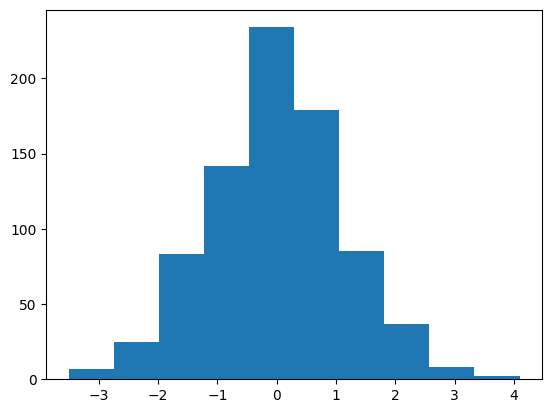

In [73]:
plt.hist(y)

In [74]:
# low_corr = X.corrwith(y).abs() < 0.01
# X = X.drop(columns=low_corr[low_corr].index)

# len(X.columns)

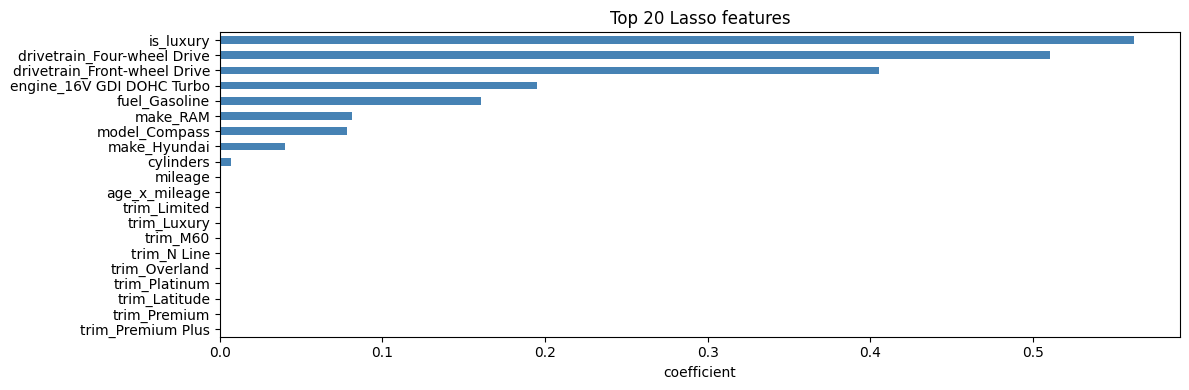

In [75]:
lasso = LassoCV(cv=5, max_iter=5000, random_state=42)
lasso.fit(X, y)

imp = pd.Series(np.abs(lasso.coef_), index=X.columns).sort_values(ascending=False)

top20 = imp.head(20)
plt.figure(figsize=(12, 4))
top20.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('coefficient')
plt.title('Top 20 Lasso features')
plt.tight_layout()
plt.show()

# Model

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=seed)

In [77]:
def evaluate(model):
    cv = cross_val_score(model, X_train, y_train, cv=3, scoring='r2', n_jobs=-1)
    scores = cv.mean() - cv.std()

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = r2_score(preds, y_test)

    return scores.item(), score

In [78]:
lr = Ridge(random_state=seed)

evaluate(lr)

(-0.5627195441608368, 0.8473564815184372)

In [79]:
gb = GradientBoostingRegressor(
    max_depth=5,
    n_estimators=500,
    random_state=seed)

evaluate(gb)

(0.7634816477955046, 0.8758471398865662)

In [80]:
cb = catboost.CatBoostRegressor(early_stopping_rounds=20, learning_rate=0.1, random_state=seed, verbose=False)

evaluate(cb)

(0.7869097107638832, 0.876447496293767)

In [81]:
st = StackingRegressor(
    estimators=[('lr', lr), ('gb', gb), ('cb', cb)],
    n_jobs=-1
)

evaluate(st)

(0.4918253335816408, 0.8898359116747749)

In [82]:
model = st
model.fit(X, y)

StackingRegressor(estimators=[('lr', Ridge(random_state=42)),
                              ('gb',
                               GradientBoostingRegressor(max_depth=5,
                                                         n_estimators=500,
                                                         random_state=42)),
                              ('cb',
                               <catboost.core.CatBoostRegressor object at 0x7f81e8275760>)],
                  n_jobs=-1)

# Submission

In [83]:
df1.groupby("cylinders")["price"].mean()

cylinders
0.0    66045.0
3.0    32673.4
4.0    39708.5
6.0    59125.3
8.0    57087.3
Name: price, dtype: float64

In [84]:
subtask1 = df1.groupby("cylinders")["price"].mean().max()

subtask2 = pt.inverse_transform(model.predict(test).astype(np.float64).reshape(-1, 1)).reshape(-1)

In [85]:
def build_subtask(sid, answers):
    return pd.DataFrame({
        "subtaskID": sid,
        "datapointID": test_ids if sid == 2 else [1],
        "answer": answers
    })

subtasks = [
    (1, subtask1),
    (2, subtask2)
]

submission = pd.concat([build_subtask(sid, ans) for (sid, ans) in subtasks])
submission = submission.astype({'answer': np.float64})
pd.set_option("display.precision", 1)

In [86]:
submission.head()

,subtaskID,datapointID,answer
0,1,1,66045.0
0,2,803,47165.6
1,2,804,40910.6
2,2,805,28137.8
3,2,806,38218.8


In [87]:
submission.to_csv("submission.csv", index=False)